In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import RegexpTokenizer, word_tokenize
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
import time
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings



In [2]:
warnings.filterwarnings("ignore")

# 1. Baca dataset
df = pd.read_csv('../labeling/3_labeled_data.csv')
df

,stemming,inset,senti
0,chale man start dey crypto football ay kak aa ...,negative,negative
1,bitcoin orange ogsatoshis,negative,negative
2,wahyus problem besar selesai web risiko orang ...,negative,positive
3,boomer bilang underwear eh underlyingnya bitcoin,negative,negative
4,ek aisi wife main bhi deserve karta hu yaar,positive,negative
...,...,...,...
1164,raja mata uang crypto bitcoin postingan halama...,negative,negative
1165,ktk kampuni zenye market cap kubwa duniani ora...,positive,negative
1166,meinmokhtar hang keje penuh asb dah n asbn bal...,positive,positive
1167,join gabung ajar santuy bareng cryptorize mala...,positive,positive


In [3]:
X = df['stemming'].fillna('')
y = df['inset'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Jumlah data latih x: {len(X_train)}\n', f'Jumlah data latih y: {len(y_train)}')
print(f'Jumlah data uji x: {len(X_test)}\n', f'Jumlah data uji y: {len(y_test)}')


Jumlah data latih x: 935
 Jumlah data latih y: 935
Jumlah data uji x: 234
 Jumlah data uji y: 234


In [ ]:
display(X_train, X_test)

In [ ]:
y_test.value_counts()

In [4]:
tfidf_params = dict(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_features=10_000
)

print(tfidf_params)

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

kernel_configs = {
    "linear": {
        "param_grid": {
            "svm__C": [0.01, 0.1, 0.5, 1, 10, 100, 1000]
        },
        "svm_base": SVC(kernel="linear", class_weight="balanced",
                        probability=True, random_state=42)
    },
    "rbf": {
        "param_grid": {
            "svm__C":     [0.01, 0.1, 0.5, 1, 10, 100, 1000],
            "svm__gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1]
        },
        "svm_base": SVC(kernel="rbf", class_weight="balanced",
                        probability=True, random_state=42)
    },
    "poly": {
        "param_grid": {
            "svm__C":      [0.01, 0.1, 0.5, 1, 10, 100, 1000],
            "svm__gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1],
            "svm__degree": [2, 3, 4]
        },
        "svm_base": SVC(kernel="poly", class_weight="balanced",
                        probability=True, random_state=42)
    }
}

print(list(kernel_configs.keys()))

{'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 2, 'max_features': 10000}
['linear', 'rbf', 'poly']


In [7]:
cfg_linear = kernel_configs["linear"]
cfg_rbf = kernel_configs["rbf"]
cfg_poly = kernel_configs["poly"]


display(cfg_linear, cfg_rbf, cfg_poly)

{'param_grid': {'svm__C': [0.01, 0.1, 0.5, 1, 10, 100, 1000]},
 'svm_base': SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)}

{'param_grid': {'svm__C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'svm__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1]},
 'svm_base': SVC(class_weight='balanced', probability=True, random_state=42)}

{'param_grid': {'svm__C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'svm__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1],
  'svm__degree': [2, 3, 4]},
 'svm_base': SVC(class_weight='balanced', kernel='poly', probability=True, random_state=42)}

In [20]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", cfg_linear["svm_base"])
    ])

gs_linear = GridSearchCV(
    estimator=pipeline,
    param_grid=cfg_linear["param_grid"],
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=1, verbose=2
)

gs_linear.fit(X_train, y_train)

Fitting 10 folds for each of 7 candidates, totalling 70 fits
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END ........................................svm__C=0.01; total time=   0.3s
[CV] END .........................................svm__C=0.1; total time=   0.3s
[CV] END .......................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to d

In [ ]:
print(f"Best model : ", gs_linear.best_estimator_)
print(f"Best params : ", gs_linear.best_params_)
print(f"best cv f1 : ", gs_linear.best_score_)


Best model :  Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('svm',
                 SVC(C=0.5, class_weight='balanced', kernel='linear',
                     probability=True, random_state=42))])
Best params :  {'svm__C': 0.5}
best cv f1 :  0.7585461885555765


In [25]:
cv_eval_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=99)

fold_score = cross_val_score(estimator=gs_linear.best_estimator_, X=X_train, y=y_train, cv=cv_eval_strategy, scoring="f1_macro")

y_pred = gs_linear.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
print("F1 Weighted (test):", f1_score(y_test, y_pred, average='weighted'))



              precision    recall  f1-score   support

           0       0.76      0.85      0.80       123
           1       0.80      0.70      0.75       111

    accuracy                           0.78       234
   macro avg       0.78      0.77      0.78       234
weighted avg       0.78      0.78      0.78       234

F1 Weighted (test): 0.7762820512820513


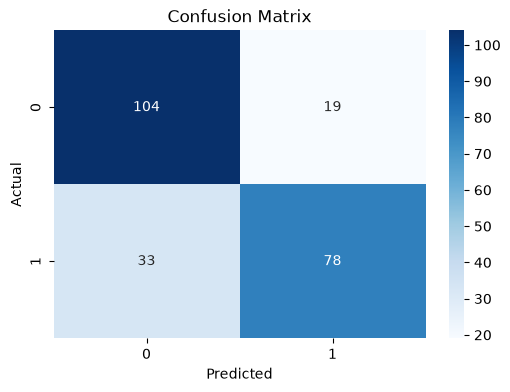

Confusion Matrix:
TP : 78
TN : 104
FP : 19
FN : 33




In [27]:
cm = confusion_matrix(y_test, y_pred)
cm

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')